<a href="https://colab.research.google.com/github/PoH-Sirius/prototype1/blob/main/Brain_signal_mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
raw_data = np.random.randn(500, 100) #500時間*100個のセンサーのデータ

data_centered = raw_data - np.mean(raw_data, axis=0) #平均との差で考える

cov_matrix = np.cov(data_centered, rowvar=False) #共分散を使い、データ同士の相関をだす

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix) #固有値と固有ベクトルを求める

idx = np.argsort(eigenvalues)[::-1] #固有値を大きい順に並べ、インデックスをidxとする
eigenvectors = eigenvectors[:, idx] #idxを使って固有ベクトルを固有値が大きい順に並べる

projection_matrix = eigenvectors[:, :2] #左2列(固有値が最大と、次に大きい)の行列をpeojection_matrixとする

reduced_data = data_centered @ projection_matrix #すべてのデータと内積をとることで二次元平面に写像

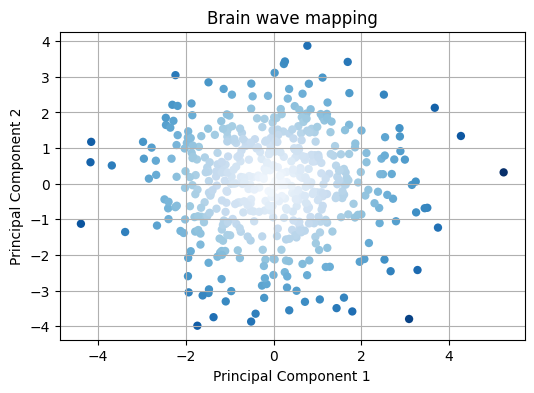

In [ ]:
distances = np.linalg.norm(reduced_data, axis=1)
color_values = distances

plt.figure(figsize=(6, 4))
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=color_values, cmap='Blues', alpha=1, edgecolors='none')
plt.title("Brain wave mapping")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()